In [1]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
survey_url = "https://raw.githubusercontent.com/altdeep/causalML/master/datasets/transportation_survey.csv"
data = pd.read_csv(survey_url)

print(data[0:5])

       A  S     E    O      R      T
0  adult  F  high  emp  small  train
1  young  M  high  emp    big    car
2  adult  M   uni  emp    big  other
3    old  F   uni  emp    big    car
4  young  F   uni  emp    big    car


In [10]:
for col in data.columns:
    print(col)
    print(data[col].unique())

A
['adult' 'young' 'old']
S
['F' 'M']
E
['high' 'uni']
O
['emp' 'self']
R
['small' 'big']
T
['train' 'car' 'other']


First, I tried some causal discovery algorithms:


*   Constraint-based: Peter-Clark (PC)
*   Score-base: Greedy Equivalence Search (GES) with BDeu score



In [ ]:
!pip install causal-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 kB 4.3 MB/s eta 0:00:00


  0%|          | 0/6 [00:00<?, ?it/s]

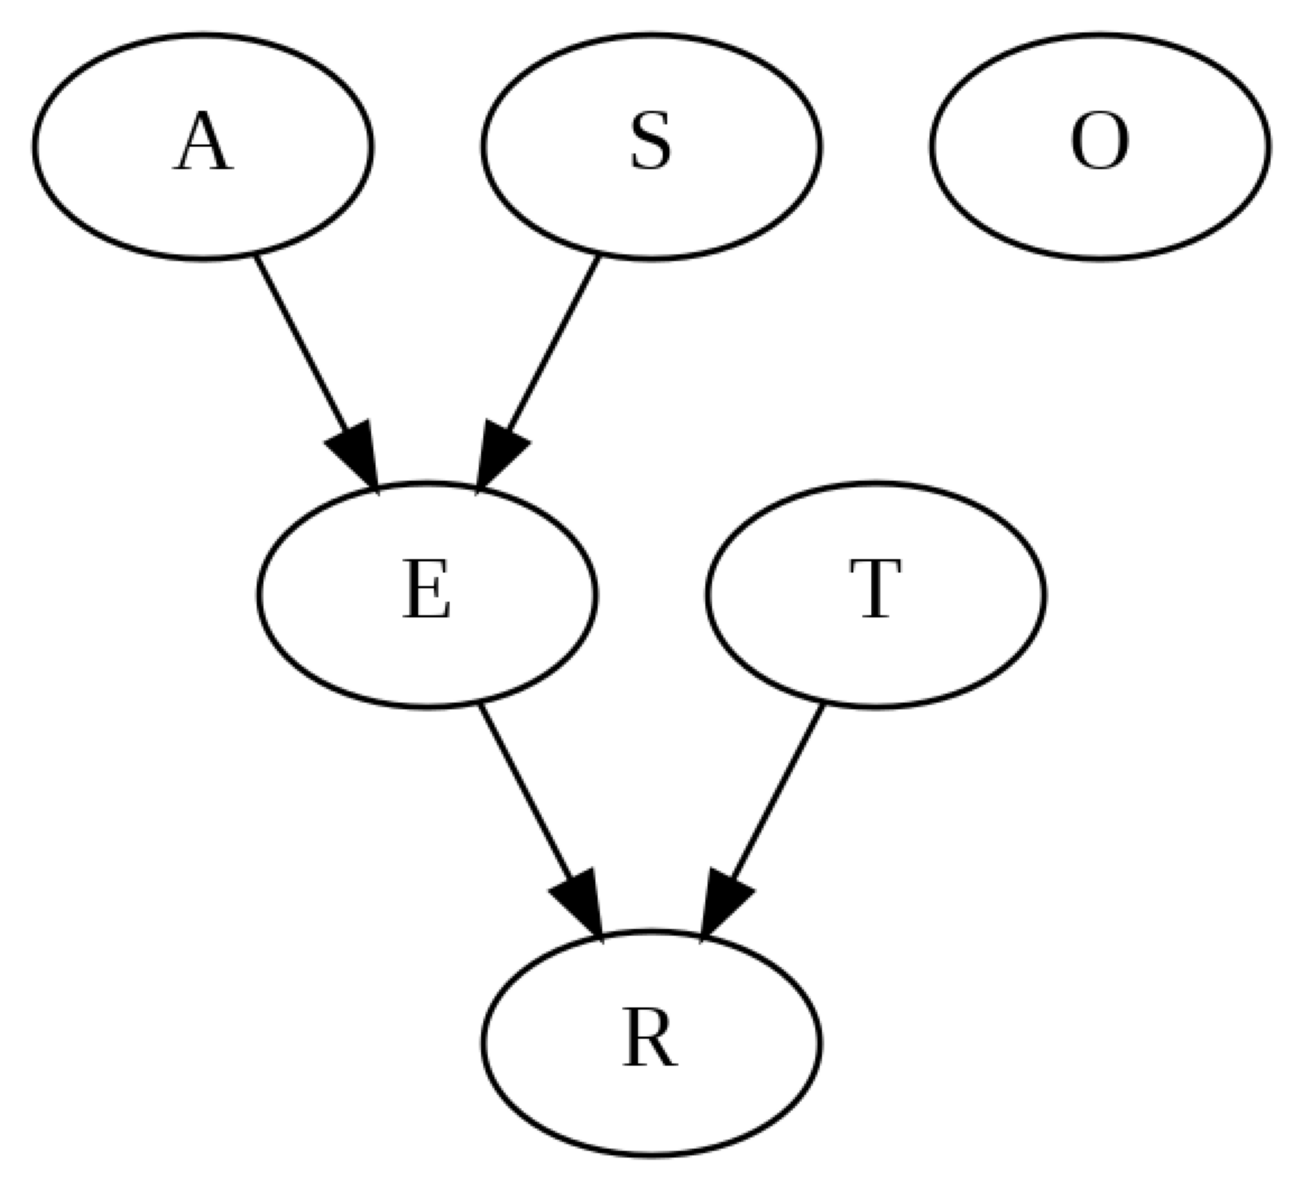

In [ ]:
import pandas as pd
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import chisq

cg = pc(data.to_numpy(), 0.05, chisq, uc_rule=1, node_names=data.columns.tolist())
cg.draw_pydot_graph()

In [ ]:
# add background knowledge of E determines O
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
bk = BackgroundKnowledge()
bk.add_required_by_node(GraphNode('E'), GraphNode('O'))

  0%|          | 0/6 [00:00<?, ?it/s]

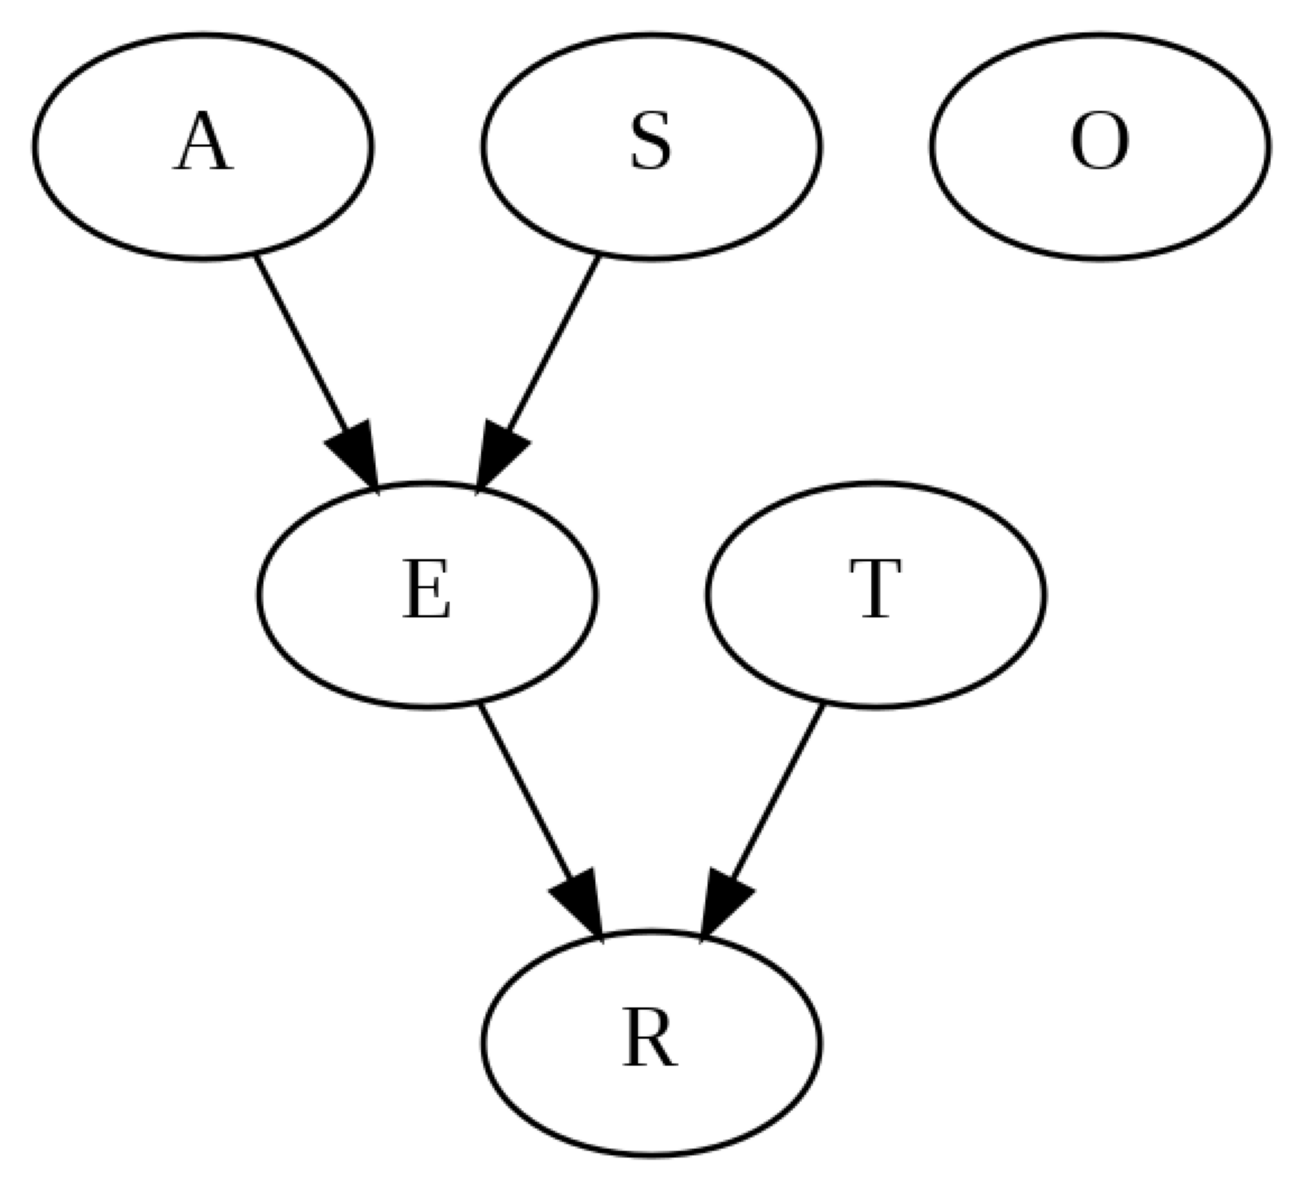

In [ ]:
cg = pc(data.to_numpy(), 0.05, chisq, uc_rule=1,background_knowledge=bk, node_names=data.columns.tolist())
cg.draw_pydot_graph()

In [ ]:
import networkx as nx
G = nx.DiGraph()
nodes = cg.G.get_nodes()
G.add_nodes_from([node.get_name() for node in nodes])
edges = cg.G.get_graph_edges()

In [ ]:
for edge in edges:
    node1 = edge.get_node1().get_name()
    node2 = edge.get_node2().get_name()

    end1 = edge.get_endpoint1()
    end2 = edge.get_endpoint2()

    if str(end1) == "TAIL" and str(end2) == "ARROW":
        G.add_edge(node1, node2)

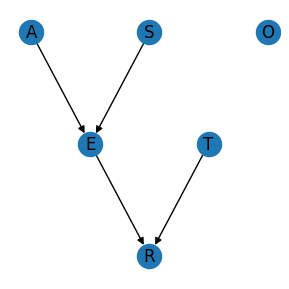

In [ ]:
plt.figure(figsize=(3, 3))
plt.axis('off')
nx.draw_networkx(G, with_labels=True, pos=nx.nx_pydot.pydot_layout(G, prog="dot"))

In [ ]:
# GES algorithm
from causallearn.search.ScoreBased.GES import ges
result = ges(data.to_numpy(), score_func='local_score_BDeu',
             node_names=data.columns.tolist())
cg_ges = result['G']

In [ ]:
G = nx.DiGraph()
nodes = cg_ges.get_nodes()
G.add_nodes_from([node.get_name() for node in nodes])
edges = cg_ges.get_graph_edges()

In [ ]:
for edge in edges:
    node1 = edge.get_node1().get_name()
    node2 = edge.get_node2().get_name()

    end1 = edge.get_endpoint1()
    end2 = edge.get_endpoint2()

    if str(end1) == "TAIL" and str(end2) == "ARROW":
        G.add_edge(node1, node2)

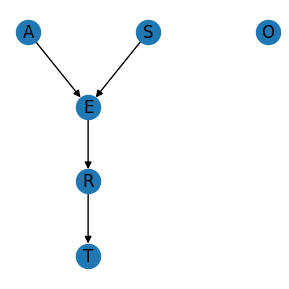

In [ ]:
plt.figure(figsize=(3, 3))
plt.axis('off')
nx.draw_networkx(G, with_labels=True, pos=nx.nx_pydot.pydot_layout(G, prog="dot"))

Causal inference testing of conditional independence:
Installed `pgmpy` module with the appropriate environment.

In [11]:
!pip install pgmpy==0.1.24
!pip install pandas==2.0.3
!pip install networkx==3.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 66.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 39.6 MB/s eta 0:00:00
  Attempting uninstall: networkx
    Found existing installation: networkx 3.6.1
    Uninstalling networkx-3.6.1:
      Successfully uninstalled networkx-3.6.1


The fact that variable O was excluded from the causal model generated by both causal discovery algorithm promoted me to check if the variable is dependend with any of the other variables at all. Pair-wise chi square test was performed. Without controlling for family-wise test error, the results show that O is independent of all variables, even the outcome T. Without association, an edge should not be drawn between O to any of the other variables.

In [ ]:
from itertools import combinations
from pgmpy.estimators.CITests import chi_square
from pgmpy.independencies import IndependenceAssertion

significance_level = 0.05
unconditional_results = {}

column_names = data.columns.tolist()

for col1, col2 in combinations(column_names, 2):
    test_result = chi_square(
        X=col1, Y=col2, Z=[],
        data=data,
        boolean=True,
        significance_level=significance_level
    )
    assertion = IndependenceAssertion(col1, col2, [])
    unconditional_results[assertion] = test_result

print("Unconditional Chi-Square Test Results (p-value < 0.05 means dependent):")
for assertion, is_independent in unconditional_results.items():
    col1 = list(assertion.event1)[0]
    col2 = list(assertion.event2)[0]
    if not is_independent:
        print(f"  '{col1}' and '{col2}' are dependent.")
    else:
        print(f"  '{col1}' and '{col2}' are independent.")

Unconditional Chi-Square Test Results (p-value < 0.05 means dependent):
  'A' and 'S' are independent.
  'A' and 'E' are dependent.
  'A' and 'O' are independent.
  'A' and 'R' are dependent.
  'A' and 'T' are dependent.
  'S' and 'E' are dependent.
  'S' and 'O' are independent.
  'S' and 'R' are dependent.
  'S' and 'T' are independent.
  'E' and 'O' are independent.
  'E' and 'R' are dependent.
  'E' and 'T' are independent.
  'O' and 'R' are independent.
  'O' and 'T' are independent.
  'R' and 'T' are dependent.


Test the causal model discovered by PC. The colider E->R<-T is refuted by the dependence between A and T in the data.

In [12]:
from pgmpy.base import DAG

In [13]:
dag = DAG([('A','E'),
        ('S','E'),
        ('E','R'),
        ('T','R')])

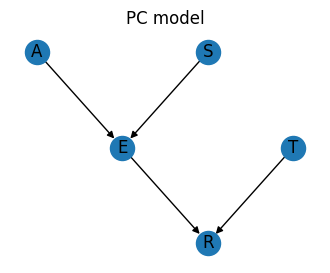

In [14]:
import networkx as nx
nx_graph = nx.DiGraph(dag.edges())

plt.figure(figsize=(4, 3))
nx.draw_networkx(nx_graph, with_labels=True, pos=nx.nx_pydot.pydot_layout(nx_graph, prog="dot"))
plt.title("PC model")
plt.axis('off')
plt.show()

In [ ]:
dseps = dag.get_independencies()

In [ ]:
from pgmpy.estimators.CITests import chi_square
from pgmpy.independencies import IndependenceAssertion

significance = 0.05
def test_dsep(dsep):
    test_outputs = []
    for X in list(dsep.get_assertion()[0]):
        for Y in list(dsep.get_assertion()[1]):
            Z = list(dsep.get_assertion()[2])
            test_result = chi_square(
                X=X, Y=Y, Z=Z,
                data=data,
                boolean=True,
                significance_level=significance
            )
            assertion = IndependenceAssertion(X, Y, Z)
            test_outputs.append((assertion, test_result))
    return test_outputs

results = [test_dsep(dsep) for dsep in dseps.get_assertions()]
results = dict([item for sublist in results for item in sublist])

In [ ]:
from pprint import pprint
pprint(results)

{(R ⟂ S | A, E): np.True_,
 (T ⟂ S | E, R): np.True_,
 (T ⟂ A | E, R): np.True_,
 (R ⟂ S | T, A, E): np.True_,
 (A ⟂ R | S, E): np.True_,
 (R ⟂ S | T, E): np.True_,
 (A ⟂ R | T, E): np.True_,
 (T ⟂ A | S, E): np.True_,
 (T ⟂ S): np.True_,
 (A ⟂ S): np.True_,
 (A ⟂ S | T): np.True_,
 (A ⟂ R | E): np.True_,
 (T ⟂ E | A, S): np.True_,
 (T ⟂ S | E): np.True_,
 (T ⟂ A | E): np.True_,
 (R ⟂ S | E): np.True_,
 (T ⟂ E): np.True_,
 (T ⟂ S | A, E): np.True_,
 (T ⟂ S | A, E, R): np.True_,
 (T ⟂ E | S): np.True_,
 (T ⟂ A | S, E, R): np.True_,
 (T ⟂ A | S): np.True_,
 (T ⟂ A): np.False_,
 (T ⟂ S | A): np.True_,
 (A ⟂ R | T, S, E): np.True_,
 (T ⟂ E | A): np.True_}


Test the causal model discovered by GES. This model is not refutable.

In [16]:
dag = DAG([('A','E'),
        ('S','E'),
        ('E','R'),
        ('R','T')])

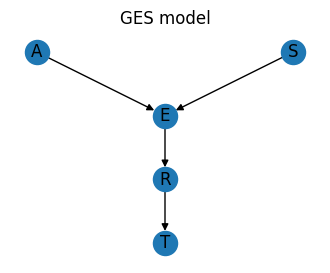

In [17]:
import networkx as nx
nx_graph = nx.DiGraph(dag.edges())

plt.figure(figsize=(4, 3))
nx.draw_networkx(nx_graph, with_labels=True, pos=nx.nx_pydot.pydot_layout(nx_graph, prog="dot"))
plt.title("GES model")
plt.axis('off')
plt.show()

In [ ]:
dseps = dag.get_independencies()

In [ ]:
from pgmpy.estimators.CITests import chi_square
from pgmpy.independencies import IndependenceAssertion

significance = 0.05
def test_dsep(dsep):
    test_outputs = []
    for X in list(dsep.get_assertion()[0]):
        for Y in list(dsep.get_assertion()[1]):
            Z = list(dsep.get_assertion()[2])
            test_result = chi_square(
                X=X, Y=Y, Z=Z,
                data=data,
                boolean=True,
                significance_level=significance
            )
            assertion = IndependenceAssertion(X, Y, Z)
            test_outputs.append((assertion, test_result))
    return test_outputs

results = [test_dsep(dsep) for dsep in dseps.get_assertions()]
results = dict([item for sublist in results for item in sublist])

In [ ]:
from pprint import pprint
pprint(results)

{(T ⟂ E | R): np.True_,
 (R ⟂ A | T, S, E): np.True_,
 (T ⟂ S | A, R, E): np.True_,
 (R ⟂ S | E): np.True_,
 (T ⟂ E | A, R): np.True_,
 (R ⟂ A | S, E): np.True_,
 (T ⟂ S | R): np.True_,
 (R ⟂ A | T, E): np.True_,
 (T ⟂ S | E): np.True_,
 (T ⟂ A | S, E): np.True_,
 (T ⟂ A | E): np.True_,
 (T ⟂ S | A, R): np.True_,
 (T ⟂ A | R, E): np.True_,
 (A ⟂ S): np.True_,
 (T ⟂ S | R, E): np.True_,
 (T ⟂ A | R, S): np.True_,
 (T ⟂ E | R, S): np.True_,
 (R ⟂ S | A, E): np.True_,
 (T ⟂ E | A, R, S): np.True_,
 (T ⟂ S | A, E): np.True_,
 (T ⟂ A | R): np.True_,
 (R ⟂ A | E): np.True_,
 (R ⟂ S | T, A, E): np.True_,
 (R ⟂ S | T, E): np.True_,
 (T ⟂ A | R, S, E): np.True_}


Making arbitrary changes of the model (swapping the positions of E and R) and test again. Many conditional independences are falsified.

In [ ]:
dag = DAG([('A','R'),
        ('S','R'),
        ('R','E'),
        ('E','T')])

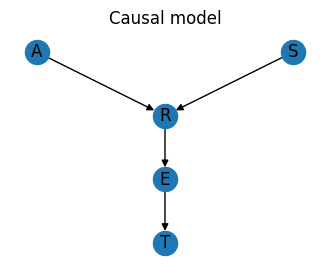

In [ ]:
nx_graph = nx.DiGraph(dag.edges())

plt.figure(figsize=(4, 3))
nx.draw_networkx(nx_graph, with_labels=True, pos=nx.nx_pydot.pydot_layout(nx_graph, prog="dot"))
plt.title("Causal model")
plt.axis('off')
plt.show()

In [ ]:
dseps = dag.get_independencies()

In [ ]:
dseps = dag.get_independencies()
significance = 0.05
def test_dsep(dsep):
    test_outputs = []
    for X in list(dsep.get_assertion()[0]):
        for Y in list(dsep.get_assertion()[1]):
            Z = list(dsep.get_assertion()[2])
            test_result = chi_square(
                X=X, Y=Y, Z=Z,
                data=data,
                boolean=True,
                significance_level=significance
            )
            assertion = IndependenceAssertion(X, Y, Z)
            test_outputs.append((assertion, test_result))
    return test_outputs

results = [test_dsep(dsep) for dsep in dseps.get_assertions()]
results = dict([item for sublist in results for item in sublist])

In [ ]:
from pprint import pprint
pprint(results)

{(T ⟂ S | R, E): np.True_,
 (S ⟂ E | R): np.False_,
 (A ⟂ E | R, S): np.False_,
 (A ⟂ E | R): np.False_,
 (T ⟂ A | S, E): np.True_,
 (S ⟂ E | T, A, R): np.False_,
 (A ⟂ E | T, R, S): np.False_,
 (T ⟂ S | E): np.True_,
 (T ⟂ S | A, E): np.True_,
 (R ⟂ T | S, E): np.False_,
 (T ⟂ A | E): np.True_,
 (A ⟂ E | T, R): np.False_,
 (R ⟂ T | A, S, E): np.False_,
 (S ⟂ E | A, R): np.False_,
 (T ⟂ A | R): np.True_,
 (A ⟂ S): np.True_,
 (T ⟂ S | A, R, E): np.True_,
 (T ⟂ S | R): np.True_,
 (S ⟂ E | T, R): np.False_,
 (T ⟂ A | R, S): np.True_,
 (T ⟂ A | R, S, E): np.True_,
 (T ⟂ A | R, E): np.True_,
 (R ⟂ T | A, E): np.False_,
 (T ⟂ S | A, R): np.True_,
 (R ⟂ T | E): np.False_}


Imposing knowledge that E determines O also result in a model that is refutable. The falsified conditional independences are all conditioned on O, suggesting incorrect connections with O. Although intuitively E should determine O, the data of O being `emp` and `self` is independent of E.

In [18]:
dag = DAG([('A','E'),
        ('S','E'),
        ('E','O'),
        ('O','R'),
        ('R','T')])

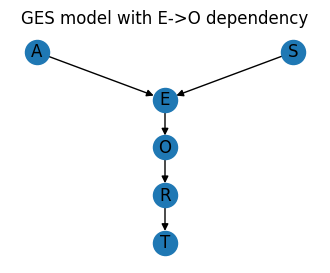

In [19]:
nx_graph = nx.DiGraph(dag.edges())

plt.figure(figsize=(4, 3))
nx.draw_networkx(nx_graph, with_labels=True, pos=nx.nx_pydot.pydot_layout(nx_graph, prog="dot"))
plt.title("GES model with E->O dependency")
plt.axis('off')
plt.show()

In [ ]:
dseps = dag.get_independencies()

In [ ]:
dseps = dag.get_independencies()
significance = 0.05
def test_dsep(dsep):
    test_outputs = []
    for X in list(dsep.get_assertion()[0]):
        for Y in list(dsep.get_assertion()[1]):
            Z = list(dsep.get_assertion()[2])
            test_result = chi_square(
                X=X, Y=Y, Z=Z,
                data=data,
                boolean=True,
                significance_level=significance
            )
            assertion = IndependenceAssertion(X, Y, Z)
            test_outputs.append((assertion, test_result))
    return test_outputs

results = [test_dsep(dsep) for dsep in dseps.get_assertions()]
results = dict([item for sublist in results for item in sublist])

In [ ]:
from pprint import pprint

print("Assertions that are FALSE (i.e., data does NOT support independence):")
false_results = {assertion: is_independent for assertion, is_independent in results.items() if not is_independent}
pprint(false_results)

Assertions that are FALSE (i.e., data does NOT support independence):
{(R ⟂ E | O, T): np.False_,
 (R ⟂ E | O, T, S): np.False_,
 (R ⟂ E | O): np.False_,
 (R ⟂ S | O, A): np.False_,
 (R ⟂ E | O, S): np.False_,
 (R ⟂ S | O): np.False_,
 (R ⟂ A | O, T, S): np.False_,
 (R ⟂ E | O, A): np.False_,
 (R ⟂ A | O, S): np.False_}
